In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')                          # auth popup, once per session
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'  # change name if you like
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(RESULTS_DIR)                                   # all relative saves now land here
print('Saving to:', os.getcwd())

Mounted at /content/drive
Saving to: /content/drive/MyDrive/thesis_results


In [2]:
# Imports

## Core libraries
import numpy as np
import matplotlib.pyplot as plt

## TensorFlow / Keras
import tensorflow as tf
import keras
from keras import ops, layers
from keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense


In [3]:
# Setting seeds

np.random.seed(1999)
tf.random.set_seed(1999)


In [4]:
# Loading the dataset

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

## Feature scaling (mapping pixel values to [0,1])
'''
This is used as neural network training via gradient descent is sensitive to the
scale of inputs (through activations a = Wx + b). This causes gradients to vanish
and makes the loss landscape poorly conditioned.
'''
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

''' Recalling our y values are our categories '''
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Setting up our validation dataset
n_val = int(0.2 * len(x_train_full))
perm = np.random.permutation(len(x_train_full))
val_idx, train_idx = perm[:n_val], perm[n_val:]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]

## Check
print(f"train: {x_train.shape} val: {x_val.shape} test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
train: (40000, 32, 32, 3) val: (10000, 32, 32, 3) test: (10000, 32, 32, 3)


In [5]:
# Augmenting the dataset
'''
This involves creating new training examples by applying label preserving
transformations to existing examples e.g. flips, crops, scaling, colour jitter,
adding noise, ...
'''

'''
Applying three transformations in sequence, we pad the image with black 0s,
then randomly crop the newly padded image (so the model learns that a shifted
horse picture is still a horse), and then randomly mirroring the image from left
to right.
'''
augment = keras.Sequential([layers.ZeroPadding2D(padding=4),
                            layers.RandomCrop(32, 32),
                            layers.RandomFlip("horizontal")])

batch_size = 128

'''
This builds the full training data pipeline, where:
- The from_tensor_slices((x_train, y_train)) wraps the numpy arrays into a
  tf.data.Dataset that has image label pairs one at a time.
- For .shuffle(len(x_train)) - this shifts the entire dataset after each epoch.
- For .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
  this applies the augmentation pipeline to each batch of images whilst leaving
  labels untouched. The training=True is important because RandomCrop and
  RandomFlip only apply their transformations during training. The
  num_parallel_calls=tf.data.AUTOTUNE lets TensorFlow decide how many batches to
  augment in parallel across CPU threads.
'''
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size).map(lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

### Recalling that there is no augmentation for validation and test datasets
val_ds  = (tf.data.Dataset.from_tensor_slices((x_val,  y_val ))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))


In [6]:
# Residual block (no dropout)
'''
Here is the specification requirements for a single residual block (the repeating
unit in ResNet-20). Instead of learning the mapping between the input and the
output, we instead learn the difference between the input and the desired output
(the residual).

In this, the shortcut path passes the input unchanged (albeit with a channel
count change to match shapes at times). These two paths are added together for
a final ReLU.
'''

### We recall that a convolution slides a small window (a kernel/filter) across our grid.
### A single kernel produces one output grid (one channel). One kernel might learn to detect vertical edges, another colour gradients, and so on.
### We thus use 16 kernels simultaneously to produce an output with 16 channels.

class ResidualBlock(keras.layers.Layer):

    '''
    The init method constructs everything which doesn't fit into the other categories.
    In this, we construct the two convolutional layers and the ReLU activation.
    Everything here is created once and reused when the block processes an input.
    Projection is handled separately, as the input's channel count changes.
    '''
    def __init__(self, filters, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride

        ### The same padding here adds just enough padding at each convolution step so the output spatial dimensions match the input.
        ### The kernel initialiser establishes starting weights for the kernels such that they are not all zero (each kernel learns the same thing), too large (where activations explode), or too small (vanishing to zero).
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")

        ### Batch normalisation ensures each channel has a mean of 0 and a variance of 1.
        ### This is necessary for faster and more stable training as the weights update during training, causing our outputs to shift considerably (and calibrated to the old weights).
        ### The purpose of batch normalisation is to ensure a stable range of outputs.
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.Activation("relu")

    ### Going deeper into the network, we want to detect increasingly abstract features.
    ### We therefore downsample (have a bigger stride) as we detect combinations.
    ### We compensate for that by increasing the number of channels.

    '''
    The build method handles the projection shortcut (and handles shape-matching if needed).
    '''
    def build(self, input_shape):
        in_channels = input_shape[-1]

        if self.stride != 1 or in_channels != self.filters:
            self.proj = layers.Conv2D(self.filters, 1, strides=self.stride, padding="valid",
                                      kernel_regularizer=keras.regularizers.L2(1e-4),
                                      kernel_initializer="he_normal")
            self.bn_proj = layers.BatchNormalization()
        else:
            self.proj = None

        super().build(input_shape)

    '''
    The call method runs the actual forward pass of the model organising the
    split into the main convolutional path and the shortcut path, then summing
    them and applying ReLU.
    '''
    def call(self, x):
        if self.proj is not None:
            shortcut = self.bn_proj(self.proj(x))
        else:
            shortcut = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.relu(out + shortcut)

    '''
    The get_config method enables serialisation so Keras can save/load the model.
    '''
    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters,
                       "stride": self.stride})
        return config


In [7]:
# build_resnet20 — deterministic / SWAG variant (no dropout)
'''
The full architecture follows the ResNet-20 spec of He et al. (2016) for CIFAR:
an initial conv, three stages of three residual blocks at filter widths
{16, 32, 64}, with the first block of stages 2 and 3 using stride 2 to halve
spatial resolution while doubling channels.
'''
def build_resnet20():
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(16, 3, padding="same",
                      kernel_regularizer=keras.regularizers.L2(1e-4),
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for _ in range(3):
        x = ResidualBlock(16)(x)

    x = ResidualBlock(32, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(32)(x)

    x = ResidualBlock(64, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(64)(x)

    ### Global average pooling takes the block's output and feeds it into a final dense layer for classification.
    ### It takes the 64 feature maps (each of which is an 8x8 grid) and averages each grid into a single number. The output is a flat vector of length 64, that feeds into the final dense layer for classification.
    ### This is therefore translation invariant (if a feature shifts position in the 8x8 grid, the average barely changes), so classification is stable.
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(10, kernel_initializer="he_normal")(x)

    return keras.Model(inputs, outputs)


In [8]:
# Loading the pre-trained deterministic ResNet-20
'''
SWAG operates in two phases (Maddox et al. 2019):
  Phase 1: standard training to convergence under a normal schedule.
  Phase 2: continued training at a higher constant learning rate, during
           which weight snapshots are collected to fit a Gaussian posterior.

For Phase 1 we re-use the deterministic checkpoint produced by the
CIFAR_10_Deterministic notebook (resnet20_best.weights.h5). This keeps the
SWAG benchmark architecturally identical to the deterministic baseline; the
only thing that changes is what we do at and after convergence.

If you've not yet run the deterministic notebook, run it first - this cell
expects the weight file to exist.
'''
swag_model = build_resnet20()
swag_model.load_weights("resnet20_best.weights.h5")

### Sanity check - the pre-trained accuracy should match what the deterministic notebook reported.
swag_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
                   loss=keras.losses.CategoricalCrossentropy(from_logits=True),
                   metrics=["categorical_accuracy"])
pre_loss, pre_acc = swag_model.evaluate(test_ds, verbose=0)
print(f"Loaded pre-trained deterministic weights. Test accuracy: {pre_acc:.4f}")


Loaded pre-trained deterministic weights. Test accuracy: 0.9111


In [9]:
# SWAG collection callback
'''
The SWAGCallback collects the running statistics needed to construct the
Gaussian posterior approximation N(theta_SWA, 1/2 (Sigma_diag + Sigma_low_rank)):

  theta_mean      = (1/T) sum_t theta_t                  (the SWA solution)
  theta_sq_mean   = (1/T) sum_t theta_t^2                (used to form Sigma_diag = theta_sq_mean - theta_mean^2)
  D_hat           = matrix whose columns are the last K deviations (theta_t - theta_mean_t)
                                                          (Sigma_low_rank = (1/(K-1)) D_hat D_hat^T)

We flatten the model's trainable weights into a single vector at the end of
every epoch in Phase 2 so the running stats can be updated as plain numpy
arrays. The unflatten helper (_flat_to_weights) is also what we'll use later
to load sampled weights back into the model for inference.
'''

class SWAGCallback(Callback):

    def __init__(self, K=20):
        super().__init__()
        self.K = K # Rank of the deviation matrix kept for the low-rank part.

        ### Storage for the running averages and the per-epoch snapshots.
        self.theta_mean = None
        self.theta_sq_mean = None
        self.n_snaps = keras.Variable(0, trainable=False)
        self.snapshots = []

    def _weights_to_flat(self):
        '''Flatten current trainable weights into a single 1D numpy array.'''
        parts = [w.numpy().ravel() for w in self.model.trainable_weights]
        return np.concatenate(parts)

    def _flat_to_weights(self, flat_theta):
        '''Inverse of _weights_to_flat - used at inference time to load sampled weights.'''
        idx = 0
        for w in self.model.trainable_weights:
            n = w.numpy().size
            w.assign(flat_theta[idx : idx + n].reshape(w.shape))
            idx = idx + n

    def on_epoch_end(self, epoch, logs=None):
        theta_i = self._weights_to_flat()
        p = len(theta_i)
        if self.theta_mean is None:
            self.theta_mean = keras.Variable(np.zeros(p), trainable=False)
            self.theta_sq_mean = keras.Variable(np.zeros(p), trainable=False)

        self.snapshots.append(theta_i.copy())
        T = len(self.snapshots)
        self.theta_mean.assign(np.mean(self.snapshots, axis=0))
        self.theta_sq_mean.assign(np.mean([s**2 for s in self.snapshots], axis=0))
        self.n_snaps.assign(self.n_snaps + 1)

        if epoch % 5 == 0:
            print(f"  [SWAG] snapshot {T:3d} collected (epoch {epoch})")

    def get_swag_params(self):
        '''
        Returns (theta_mean, theta_sq_mean, D_hat).
        D_hat columns are theta_t - mean(theta_1..t) for the last K snapshots,
        following the deviation construction in Maddox et al. (2019).
        '''
        theta_mean_np = self.theta_mean.numpy()
        theta_sq_mean_np = self.theta_sq_mean.numpy()

        deviations = []
        for i, snap in enumerate(self.snapshots):
            mean_at_i = np.mean(self.snapshots[:i+1], axis=0)
            deviations.append(snap - mean_at_i)

        D_hat = np.column_stack(deviations[-self.K:])
        return theta_mean_np, theta_sq_mean_np, D_hat


In [10]:
# Phase 2 - SWA training with constant learning rate
'''
We continue training with a constant moderately-high learning rate (here
0.001 SGD + momentum, chosen by the Summative-2 sweep over {0.001, 0.005,
0.01, 0.05} - higher rates produced unstable val_loss). The constant LR keeps
the optimiser bouncing around the loss valley rather than diving into a
single minimum, so the collected snapshots span a meaningful portion of the
posterior mode.

We collect K=30 snapshots, which exceeds the K>=20 recommendation and gives
the low-rank part of the covariance enough columns to capture the dominant
directions of weight variation.
'''
K = 30
swag_cb = SWAGCallback(K=K)

print("Running SWA phase...")
history_swa = swag_model.fit(train_ds,
                             epochs=40,
                             validation_data=val_ds,
                             callbacks=[swag_cb],
                             verbose=0)

theta_swa, theta_sq_mean, D_hat = swag_cb.get_swag_params()

np.save("theta_swa.npy", theta_swa)
np.save("theta_sq_mean.npy", theta_sq_mean)
np.save("D_hat.npy", D_hat)

print(f"\nSWAG done. theta_swa shape: {theta_swa.shape}")
print(f"D_hat shape: {D_hat.shape} -> {D_hat.shape[1]} deviation columns")


Running SWA phase...
  [SWAG] snapshot   1 collected (epoch 0)
  [SWAG] snapshot   6 collected (epoch 5)
  [SWAG] snapshot  11 collected (epoch 10)
  [SWAG] snapshot  16 collected (epoch 15)
  [SWAG] snapshot  21 collected (epoch 20)
  [SWAG] snapshot  26 collected (epoch 25)
  [SWAG] snapshot  31 collected (epoch 30)
  [SWAG] snapshot  36 collected (epoch 35)

SWAG done. theta_swa shape: (273258,)
D_hat shape: (273258, 30) -> 30 deviation columns


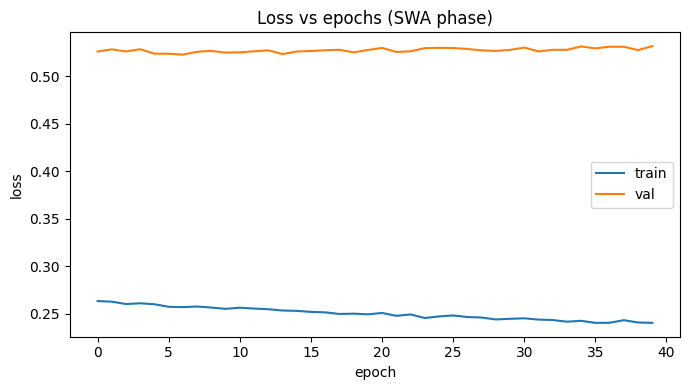

In [11]:
# Plot the SWA-phase loss curves

plt.figure(figsize=(7, 4))
plt.plot(history_swa.history["loss"], label="train")
plt.plot(history_swa.history["val_loss"], label="val")
plt.title("Loss vs epochs (SWA phase)")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.tight_layout(); plt.show()


In [12]:
# Sampling from the SWAG posterior
'''
We sample weight vectors using the identity from Maddox et al. (2019, eq. 1):

    theta_tilde = theta_SWA
                + (1 / sqrt(2)) * Sigma_diag^(1/2) * z1
                + (1 / sqrt(2 (K-1))) * D_hat * z2,
    z1 ~ N(0, I_d),  z2 ~ N(0, I_K).

The 1/2 factor on Sigma comes from averaging the diagonal and low-rank
covariance estimates. We clip the diagonal at zero to handle numerical noise
that could produce tiny negative variances.
'''
sigma_diag = theta_sq_mean - theta_swa**2
sigma_diag_sqrt = np.sqrt(np.maximum(sigma_diag, 0))
d = len(theta_swa)

def sample_swag(theta_swa, sigma_diag_sqrt, D_hat, K):
    z1 = np.random.randn(d)
    z2 = np.random.randn(K)
    return (theta_swa
            + (1 / np.sqrt(2)) * sigma_diag_sqrt * z1
            + (1 / np.sqrt(2 * (K - 1))) * D_hat @ z2)


In [13]:
# Loading SVHN as the out-of-distribution reference set
'''
Per the proposal §3.5, SVHN (street view of house numbers) is used as the
OOD test set. SVHN images are 32x32 colour photos like CIFAR-10, but of
digits, so a CIFAR-10 trained model should ideally report higher predictive
entropy on SVHN inputs than on its in-distribution CIFAR-10 test images.

The whole SVHN test split is ~26k examples; we load it via
tensorflow_datasets and rescale to [0, 1] to match CIFAR-10 preprocessing.
'''
import tensorflow_datasets as tfds

svhn = tfds.load("svhn_cropped", split="test", as_supervised=True)
svhn_images = []
for img, _ in svhn:
    svhn_images.append(img.numpy())
x_svhn = np.stack(svhn_images).astype("float32") / 255.0

print(f"SVHN OOD set: {x_svhn.shape}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.QOVO3H_3.1.0/svhn_cropped-train.tfrecord-[0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.QOVO3H_3.1.0/svhn_cropped-test.tfrecord-[0-9][0-9]…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.QOVO3H_3.1.0/svhn_cropped-extra.tfrecord-[0-9][0-9…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.
SVHN OOD set: (26032, 32, 32, 3)


In [14]:
# SWAG predictive distribution (S samples)
'''
The posterior predictive estimate averages model outputs over S weight
samples from the SWAG Gaussian:
    p(y* | x*, D) ~= (1/S) sum_s p(y* | x*, theta_s),    theta_s ~ q_SWAG(theta).

For each weight sample we forward-pass the entire test set (and SVHN). This
is more expensive than MC Dropout because each sample requires loading new
weights into the model, but the prediction itself is deterministic per
sample (no extra stochasticity at inference).

We also save the per-sample probabilities so the evaluation file can
compute the mutual-information uncertainty decomposition.
'''
S = 30

### Save the current (SWA mean) weights so we can restore them after sampling.
original_weights = [w.numpy().copy() for w in swag_model.trainable_weights]

def swag_predictive(x_ds_or_array, S=S, batch_size=128):
    if isinstance(x_ds_or_array, np.ndarray):
        ds = tf.data.Dataset.from_tensor_slices(x_ds_or_array).batch(batch_size)
        get_x = lambda b: b
    else:
        ds = x_ds_or_array
        get_x = lambda b: b[0]

    samples = []
    for s in range(S):
        ### Draw a fresh weight sample and load it into the model.
        theta_s = sample_swag(theta_swa, sigma_diag_sqrt, D_hat, K)
        swag_cb._flat_to_weights(theta_s)

        per_sample = []
        for batch in ds:
            x_batch = get_x(batch)
            logits = swag_model(x_batch, training=False)
            per_sample.append(tf.nn.softmax(logits, axis=-1).numpy())
        samples.append(np.concatenate(per_sample, axis=0))

    all_probs = np.stack(samples, axis=0)              # (S, N, 10)
    return all_probs, all_probs.mean(axis=0)

print("Running SWAG inference on CIFAR-10 test set...")
all_probs_test, probs_test = swag_predictive(test_ds, S=S)
preds_test  = np.argmax(probs_test, axis=1)
labels_test = np.argmax(y_test, axis=1)
print(f"SWAG (S={S}) test accuracy: {(preds_test == labels_test).mean():.4f}")

print("Running SWAG inference on SVHN OOD set...")
all_probs_svhn, probs_svhn = swag_predictive(x_svhn, S=S)

### Restore the SWA mean weights (good housekeeping in case downstream cells use the model).
for w, orig in zip(swag_model.trainable_weights, original_weights):
    w.assign(orig)

print(f"all_probs_test: {all_probs_test.shape}")
print(f"all_probs_svhn: {all_probs_svhn.shape}")


Running SWAG inference on CIFAR-10 test set...
SWAG (S=30) test accuracy: 0.9090
Running SWAG inference on SVHN OOD set...
all_probs_test: (30, 10000, 10)
all_probs_svhn: (30, 26032, 10)


In [15]:
# Saving raw outputs for the evaluation file
'''
Same .npz schema as the other two benchmarks. The S=30 per-sample arrays
allow the eval file to compute the same MI-style epistemic / aleatoric
decomposition used for MC Dropout, so the two BNN baselines are directly
comparable.
'''
np.savez("swag_results.npz",
         model_name="swag",
         probs_test=probs_test,
         labels_test=labels_test,
         preds_test=preds_test,
         probs_svhn=probs_svhn,
         all_probs_test=all_probs_test,
         all_probs_svhn=all_probs_svhn)

print("Saved swag_results.npz")


Saved swag_results.npz
